## Practical 7

# Setup and Loading Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# Load the cleaned dataset
df = pd.read_csv('../data/heart_clean.csv')

# Display the first few rows
display(df.head())

,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,...,num,cp_atypical angina,cp_non-anginal,cp_typical angina,thal_normal,thal_reversable defect,slope_flat,slope_upsloping,restecg_normal,restecg_st-t abnormality
0,-1.730169,1.007386,Male,Cleveland,0.698041,0.311021,True,0.495698,False,1.349421,...,0,False,False,True,False,False,False,False,False,False
1,-1.726404,1.432034,Male,Cleveland,1.511761,0.797713,False,-1.175955,True,0.589832,...,2,False,False,False,True,False,True,False,False,False
2,-1.722639,1.432034,Male,Cleveland,-0.658158,0.274289,False,-0.340128,True,1.634267,...,1,False,False,False,False,True,True,False,False,False
3,-1.718873,-1.752828,Male,Cleveland,-0.115679,0.467130,False,1.968345,False,2.488805,...,0,False,True,False,True,False,False,False,True,False
4,-1.715108,-1.328180,Female,Cleveland,-0.115679,0.044717,False,1.371326,False,0.494884,...,0,True,False,False,True,False,False,True,False,False


# Define Features (X) and Target (y)

In [3]:

y = df['thalch']


X = df.drop(columns=['thalch', 'num', 'id', 'dataset'], errors='ignore')

X = pd.get_dummies(X, drop_first=True)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (920, 17)
Target (y) shape: (920,)


# Method 1 - Simple Validation

In [4]:

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

alphas = [1e-3, 0.01, 0.1, 1, 10, 100, 1000]

simple_train_err = []
simple_val_err = []

print("--- Simple Validation Results ---")
for alpha in alphas:
    # Train Ridge model
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    
    # Calculate Mean Squared Error
    mse_train = mean_squared_error(y_train, ridge.predict(X_train))
    mse_val = mean_squared_error(y_val, ridge.predict(X_val))
    
    simple_train_err.append(mse_train)
    simple_val_err.append(mse_val)
    
    print(f"Alpha={alpha:7.3f} | Train MSE={mse_train:.4f} | Validation MSE={mse_val:.4f}")

--- Simple Validation Results ---
Alpha=  0.001 | Train MSE=0.6095 | Validation MSE=0.7461
Alpha=  0.010 | Train MSE=0.6095 | Validation MSE=0.7461
Alpha=  0.100 | Train MSE=0.6095 | Validation MSE=0.7461
Alpha=  1.000 | Train MSE=0.6095 | Validation MSE=0.7453
Alpha= 10.000 | Train MSE=0.6109 | Validation MSE=0.7408
Alpha=100.000 | Train MSE=0.6400 | Validation MSE=0.7352
Alpha=1000.000 | Train MSE=0.8000 | Validation MSE=0.8034


# Method 2 - 5-Fold Cross-Validation

In [6]:
cv_train_err = []
cv_val_err = []

print("--- 5-Fold Cross-Validation Results ---")
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    
    
    scores = cross_validate(ridge, X, y, cv=5, 
                            scoring='neg_mean_squared_error', 
                            return_train_score=True)
    
    # cross_validate returns negative values for MSE, so we multiply by -1 to make them positive
    mse_train = -np.mean(scores['train_score'])
    mse_val = -np.mean(scores['test_score'])
    
    cv_train_err.append(mse_train)
    cv_val_err.append(mse_val)
    
    print(f"Alpha={alpha:7.3f} | Train MSE={mse_train:.4f} | CV MSE={mse_val:.4f}")

--- 5-Fold Cross-Validation Results ---
Alpha=  0.001 | Train MSE=0.6246 | CV MSE=0.7117
Alpha=  0.010 | Train MSE=0.6246 | CV MSE=0.7117
Alpha=  0.100 | Train MSE=0.6246 | CV MSE=0.7117
Alpha=  1.000 | Train MSE=0.6246 | CV MSE=0.7116
Alpha= 10.000 | Train MSE=0.6261 | CV MSE=0.7128
Alpha=100.000 | Train MSE=0.6544 | CV MSE=0.7542
Alpha=1000.000 | Train MSE=0.7958 | CV MSE=0.9314


# Visualizing and Comparing the Results

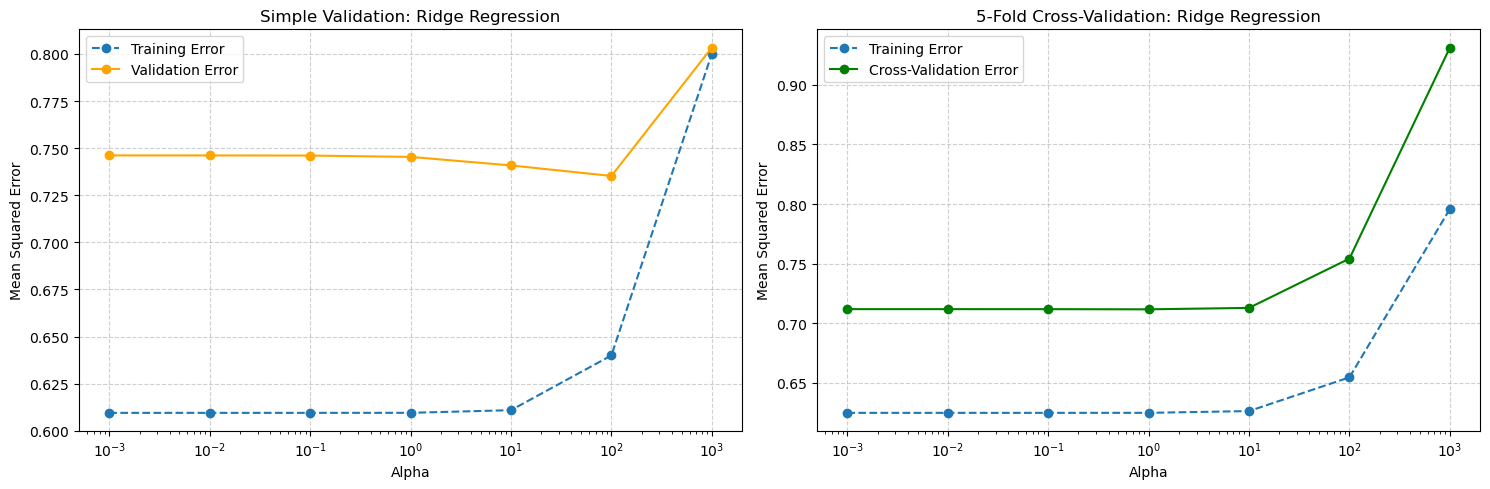


Conclusion: Based on Cross-Validation, the best performing Alpha is 1


In [7]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Simple Validation
axes[0].plot(alphas, simple_train_err, 'o--', label='Training Error')
axes[0].plot(alphas, simple_val_err, 'o-', label='Validation Error', color='orange')
axes[0].set_xscale('log') # Log scale because our alphas multiply by 10 each time
axes[0].set_title('Simple Validation: Ridge Regression')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Mean Squared Error')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Cross-Validation
axes[1].plot(alphas, cv_train_err, 'o--', label='Training Error')
axes[1].plot(alphas, cv_val_err, 'o-', label='Cross-Validation Error', color='green')
axes[1].set_xscale('log')
axes[1].set_title('5-Fold Cross-Validation: Ridge Regression')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Mean Squared Error')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Find the best alpha according to the more reliable Cross-Validation method
best_alpha_index = np.argmin(cv_val_err)
best_alpha = alphas[best_alpha_index]
print(f"\nConclusion: Based on Cross-Validation, the best performing Alpha is {best_alpha}")